In [2]:
import jax
import jax.numpy as jnp
import inspeqtor as sq
from functools import partial
from alive_progress import alive_bar
import scienceplots as scienceplots
import matplotlib.pyplot as plt
from shared import get_predefined_data_model_m1, bound, train_model, colors
import polars as pl
import seaborn as sns
import statistics

plt.style.use("science")

sq.experimental.utils.enable_jax_x64()
calculate_agf_sx = sq.physics.direct_AGF_estimation_fn(sq.constant.SX)
DETUNE = 0.0005
shots_list = [100, 1_000, 10_000, 100_000]
# shots_list = [1_00]

In [4]:
import numpy as np


def format_value(val, scientific_threshold, precision):
    """Format a single value."""
    # String or header
    if isinstance(val, str):
        return val

    # Integer
    if isinstance(val, (int, np.integer)):
        return str(val)

    # Float - check if scientific notation needed
    if isinstance(val, (float, np.floating)):
        if abs(val) < scientific_threshold and val != 0:
            # Scientific notation
            formatted = f"{val:.{precision}e}"
            mantissa, exponent = formatted.split("e")
            exponent = int(exponent)
            return f"${mantissa} \\times 10^{{{exponent}}}$"
        else:
            # Regular decimal
            return f"{val:.{precision}f}"

    return str(val)


def pra_table(
    data, caption="", label="tab:label", precision=4, scientific_threshold=1e-2
):
    """
    Generate a Physical Review A style LaTeX table.

    Args:
        data: List of lists, first row is header
        caption: Table caption (goes above table, PRA style)
        label: Label for referencing
        precision: Number of decimal places (default: 4)
        scientific_threshold: Use scientific notation if |value| < threshold (default: 1e-3)

    Returns:
        str: LaTeX table code ready for PRA submission
    """

    header = data[0]
    rows = data[1:]
    n_cols = len(header)

    # Column alignment: center for first, right-align for numbers
    col_spec = "l" + "r" * (n_cols - 1)

    # Build LaTeX
    lines = [
        "\\begin{table}[htbp]",
        "\\centering",
        f"\\begin{{ruledtabular}}\\begin{{tabular}}{{{col_spec}}}",
        " & ".join([f"\\textbf{{{h}}}" for h in header]) + " \\\\",
        "\\midrule",
    ]

    # Add data rows
    for row in rows:
        formatted_row = [
            format_value(val, scientific_threshold, precision) for val in row
        ]
        lines.append(" & ".join(formatted_row) + " \\\\")

    lines.extend(
        [
            "\\end{tabular}",
            f"\\end{{ruledtabular}}\\caption{{{caption}}}",
            f"\\label{{{label}}}",
            "\\end{table}",
        ]
    )

    return "\n".join(lines)

In [3]:
def generate_data(key: jnp.ndarray, shot: int):
    data_model = get_predefined_data_model_m1(DETUNE)
    assert data_model.whitebox

    quantum_device = partial(
        sq.experimental.utils.shot_quantum_device,
        solver=data_model.solver,
        SHOTS=shot,
        expectation_value_receipt=sq.constant.default_expectation_values_order,
    )

    data_model.quantum_device = quantum_device

    exp_data, *_ = sq.predefined.generate_single_qubit_experimental_data(
        key,
        data_model.total_hamiltonian,
        sample_size=1000,
        shots=shot,
        qubit_inforamtion=data_model.qubit_information,
        control_sequence=data_model.control_sequence,
        method=sq.experimental.predefined.WhiteboxStrategy.TROTTER,
        trotter_steps=10_000,
    )

    sq.predefined.save_data_to_path(
        f"./shot-exp/{shot}/data",
        experiment_data=exp_data,
        control_sequence=data_model.control_sequence,
    )


def gen_data(key: jnp.ndarray, shot: int, sample_size: int):
    data_model = get_predefined_data_model_m1(DETUNE)
    assert data_model.whitebox

    exp_data, *_ = sq.predefined.generate_single_qubit_experimental_data(
        key,
        data_model.total_hamiltonian,
        sample_size=sample_size,
        shots=shot,
        qubit_inforamtion=data_model.qubit_information,
        control_sequence=data_model.control_sequence,
        method=sq.experimental.predefined.WhiteboxStrategy.TROTTER,
        trotter_steps=10_000,
    )

    loaded_data = sq.utils.prepare_data(
        exp_data, data_model.control_sequence, data_model.whitebox
    )

    test_data = sq.optimize.DataBundled(
        control_params=sq.experimental.predefined.drag_feature_map(
            loaded_data.control_parameters
        ),
        unitaries=loaded_data.unitaries,
        observables=loaded_data.observed_values,
    )

    return test_data


def prepare_data(key: jnp.ndarray, shot: int):
    loaded_data = sq.predefined.load_data_from_path(
        f"./shot-exp/{shot}/data",
        sq.experimental.predefined.HamiltonianSpec(
            method=sq.experimental.predefined.WhiteboxStrategy.TROTTER,
            hamiltonian_enum=sq.experimental.predefined.HamiltonianEnum.rotating_transmon_hamiltonian,
            trotter_steps=10000,
        ),
    )

    # Here, we just bundling things up for convinience uses.
    test_ratio = 0.1
    (
        train_control_parameters,
        train_unitaries,
        train_expectation_values,
        test_control_paramaeters,
        test_unitaries,
        test_expectation_values,
    ) = sq.experimental.utils.random_split(
        key,
        int(loaded_data.control_parameters.shape[0] * test_ratio),  # Test size
        loaded_data.control_parameters,
        loaded_data.unitaries,
        loaded_data.observed_values,
    )

    train_data = sq.optimize.DataBundled(
        control_params=sq.experimental.predefined.drag_feature_map(
            train_control_parameters
        ),
        unitaries=train_unitaries,
        observables=train_expectation_values,
    )

    test_data = sq.optimize.DataBundled(
        control_params=sq.experimental.predefined.drag_feature_map(
            test_control_paramaeters
        ),
        unitaries=test_unitaries,
        observables=test_expectation_values,
    )

    return loaded_data, train_data, test_data


def train_predictive_model(key: jnp.ndarray, train_data, test_data, shot: int):
    NUM_EPOCH = 5000
    optimizer = sq.optimize.get_default_optimizer(8 * NUM_EPOCH)

    model = sq.models.linen.WoModel(
        shared_layers=[10],
        pauli_layers=[10],
    )

    loss_fn = sq.models.linen.make_loss_fn(
        adapter_fn=sq.model.observable_to_expvals,
        model=model,
        calculate_metric_fn=sq.model.calculate_metric,
        loss_metric=sq.model.LossMetric.MSEE,
    )

    with alive_bar(NUM_EPOCH, title="Training 🚀", force_tty=True) as bar:
        model_params, opt_state, histories = train_model(
            key,
            train_data=train_data,
            val_data=test_data,  # Here, we did not care about the validating dataset.
            test_data=test_data,
            model=model,
            optimizer=optimizer,
            loss_fn=loss_fn,
            callbacks=[lambda x, y, z: bar()],
            NUM_EPOCH=NUM_EPOCH,
        )

    model_state = sq.model.ModelData(
        params=model_params,
        config={
            "shared_layers": model.shared_layers,
            "pauli_layers": model.shared_layers,
        },
    )

    model_state.to_file(f"./shot-exp/{shot}/model/model.json")

    df = pl.DataFrame(sq.experimental.optimize.clean_history_entries(histories))

    df.write_csv(f"./shot-exp/{shot}/model/train_hist.csv")

    return df


def calibrate_control(key, loaded_data, shot: int):
    model_state = sq.model.ModelData.from_file(f"./shot-exp/{shot}/model/model.json")

    model = sq.models.linen.WoModel(**model_state.config)
    predictive_fn = sq.models.linen.make_predictive_fn(
        sq.model.observable_to_expvals, model, model_state.params
    )

    # key, params_key = jax.random.split(key)
    ravel_fn, unravel_fn = sq.control.ravel_unravel_fn(loaded_data.control_sequence)
    # sample_params = ravel_fn(loaded_data.control_sequence.sample_params(params_key))

    def embed_predictive_model(control_parameters: jnp.ndarray):
        unitary_f = loaded_data.whitebox(control_parameters)[-1]
        return predictive_fn(
            sq.experimental.predefined.drag_feature_map(control_parameters), unitary_f
        )

    @jax.jit
    def average_gate_infidelity(params: jnp.ndarray):
        # Predict the expectation values
        predicted_expvals = embed_predictive_model(params)
        # Calculate the average gate fidelity with respected to SX gate.
        AGF = calculate_agf_sx(predicted_expvals)
        # return average gate infidelity squared and log the results.
        return (1 - AGF), {"AGF": AGF}

    # init_params = ravel_fn(loaded_data.control_sequence.sample_params(key))
    init_params = jnp.array([jnp.pi / 2, 5.])

    lower, upper = loaded_data.control_sequence.get_bounds()

    steps = 1000
    with alive_bar(steps, title="Optimizing 🚀", force_tty=True) as bar:
        optimized_params, aux = sq.optimize.minimize(
            init_params,
            average_gate_infidelity,
            sq.optimize.get_default_optimizer(int(steps)),
            ravel_fn(lower),
            ravel_fn(upper),
            maxiter=steps,
            callbacks=[lambda step, aux: bar()],
        )

    predicted_agf = aux[-1]["AGF"].item()
    assert isinstance(optimized_params, jnp.ndarray)

    sq.experimental.data.save_pytree_to_json(
        {"predicted_agf": predicted_agf, "optimized_params": optimized_params},
        f"./shot-exp/{shot}/model/optimized_control.json",
    )

    return predicted_agf, optimized_params


def benchmark(
    key,
    shots: int,
    whitebox,
    detune: float = DETUNE,
    filename: str = "benchmark_result.json",
):
    model_state = sq.model.ModelData.from_file(f"./shot-exp/{shots}/model/model.json")

    optimized_results = sq.experimental.data.load_pytree_from_json(
        f"./shot-exp/{shots}/model/optimized_control.json",
    )

    optimized_params = optimized_results["optimized_params"]

    model = sq.models.linen.WoModel(**model_state.config)
    data_model = get_predefined_data_model_m1(detune=detune)
    sample_size = 500
    device_key, predict_key = jax.random.split(key)

    quantum_device = partial(
        sq.experimental.utils.shot_quantum_device,
        solver=data_model.solver,
        SHOTS=shots,
        expectation_value_receipt=sq.constant.default_expectation_values_order,
    )

    device_key, predict_key = jax.random.split(key)
    device_expvals = quantum_device(
        device_key, jnp.broadcast_to(optimized_params, (sample_size, 2))
    )
    device_agfs = jax.vmap(calculate_agf_sx)(device_expvals)

    predictive_model = sq.probabilistic.make_predictive_resampling_model(
        sq.models.linen.make_predictive_fn(
            sq.models.observable_to_expvals, model, model_state.params
        ),
        shots,
    )

    unitary_f = whitebox(optimized_params)[-1]

    predicted_expvals = jax.vmap(predictive_model, in_axes=(0, None, None))(
        jax.random.split(predict_key, sample_size),
        sq.experimental.predefined.drag_feature_map(optimized_params),
        unitary_f,
    )

    predicted_agfs = jax.vmap(calculate_agf_sx)(predicted_expvals)

    def exact_quantum_device(params: jnp.ndarray):
        return sq.model.get_predict_expectation_value(
            {"X": sq.constant.X, "Y": sq.constant.Y, "Z": sq.constant.Z},
            data_model.solver(params)[-1],
            sq.constant.default_expectation_values_order,
        )

    exact_expvals = exact_quantum_device(optimized_params)
    exact_agf = calculate_agf_sx(exact_expvals)
    exact_agf.item()

    benchmark_result = {"Device": device_agfs, "Model": predicted_agfs}

    sq.experimental.data.save_pytree_to_json(
        {"exact_agf": exact_agf, "benchmark_result": benchmark_result},
        f"./shot-exp/{shots}/model/{filename}",
    )

    return benchmark_result, exact_agf

In [ ]:
key = jax.random.key(1)
for shots in shots_list:
    key, gen_key, data_key, train_key, control_key, benchmark_key = jax.random.split(
        key, 6
    )

    generate_data(gen_key, shots)

    loaded_data, train_data, test_data = prepare_data(data_key, shots)
    df = train_predictive_model(train_key, train_data, test_data, shots)
    predicted_agf, optimized_params = calibrate_control(
        control_key, loaded_data, shots
    )

    benchmark_results, exact_agf = benchmark(
        benchmark_key, shots, loaded_data.whitebox, detune=DETUNE
    )

In [5]:
key = jax.random.key(2)
testing_datasets = {}
for shots in shots_list:
    key, subkey = jax.random.split(key)
    testing_datasets[shots] = gen_data(subkey, shots, sample_size=1_000)

In [6]:
squared_error_dict = {}
for shots in shots_list:
    model_state = sq.model.ModelData.from_file(f"./shot-exp/{shots}/model/model.json")

    model = sq.models.linen.WoModel(**model_state.config)
    predictive_fn = sq.models.linen.make_predictive_fn(
        sq.model.observable_to_expvals, model, model_state.params
    )

    predicted_expvals = predictive_fn(
        testing_datasets[shots].control_params, testing_datasets[shots].unitaries
    )
    se = jax.vmap(sq.models.mse)(predicted_expvals, testing_datasets[shots].observables)
    squared_error_dict[shots] = se

0.006936283925045362 0.00026961725837869495 0.014220159766473133
0.0006970124555462789 3.0345788879612224e-05 0.004770675178599898
0.00010068494885710163 3.401828219043496e-05 0.0050511099416688824
1.561586025779593e-05 8.949193591129262e-06 0.002590732559209257


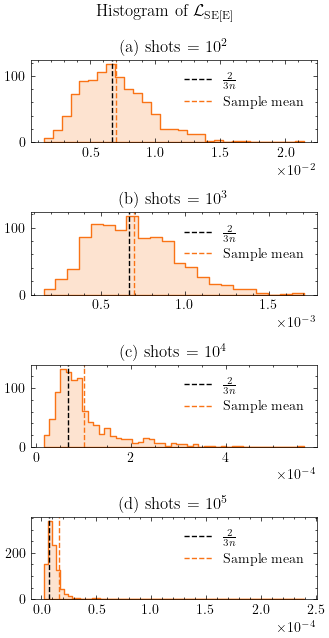

In [7]:
rows: list[list[str | float | int]] = [
    ["Shots", "Loss", "Optimality (Est.)", "Bound (RHS)"]
]

default_figsize = jnp.array((3.5, 2.625))
fig, axes = plt.subplots(4, 1, figsize=default_figsize * jnp.array([1, 2.5]))
axes = sq.visualization.assert_list_of_axes(axes)
for idx, (shots, ax) in enumerate(zip(shots_list, axes)):
    se = squared_error_dict[shots]
    s = sns.histplot(
        np.array(se), element="step", color=colors["orange"], alpha=0.2, ax=ax
    )
    s.axvline(
        2 / (3 * shots), color="black", linestyle="dashed", label=r"$\frac{2}{3n}$"
    )
    expected_loss = statistics.mean(np.array(se))
    s.axvline(
        expected_loss, color=colors["orange"], linestyle="dashed", label="Sample mean"
    )
    ax.set_ylabel("")
    # Add subplot title with label and shot count
    label = chr(97 + idx)  # 97 is ASCII for 'a'
    
    ax.ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))
    ax.legend()

    print(expected_loss, expected_loss - 2 / (3 * shots), bound(expected_loss, shots))

    formatted_shot = f"{shots:.0e}"
    mantissa, exponent = formatted_shot.split('e')
    exponent = int(exponent)
    
    rows.append(
        [
            f"$10^{exponent}$",
            expected_loss,
            expected_loss - 2 / (3 * shots),
            bound(expected_loss, shots).item()
        ]
    )

    ax.set_title(f"({label}) shots = $10^{exponent}$")

fig.suptitle(r"Histogram of $\mathcal{L}_{\text{SE[E]}}$")

fig.tight_layout()
fig.savefig("figure_histogram_test_se.pdf")

In [8]:
print(
    pra_table(
        rows,
        caption=r"For each $n$, we list the average $\mseeloss$ loss of test dataset consist of 1000 sample. From the test loss, we estimate the empirical optimality, and then use them to calculate the RHS of the bound in \cref{eq:agf-bound-alt}.",
        label="tab:shot-exp-training-stats",
        scientific_threshold=0.1
    )
)

\begin{table}[htbp]
\centering
\begin{ruledtabular}\begin{tabular}{lrrr}
\textbf{Shots} & \textbf{Loss} & \textbf{Optimality (Est.)} & \textbf{Bound (RHS)} \\
\midrule
$10^2$ & $6.9363 \times 10^{-3}$ & $2.6962 \times 10^{-4}$ & $1.4220 \times 10^{-2}$ \\
$10^3$ & $6.9701 \times 10^{-4}$ & $3.0346 \times 10^{-5}$ & $4.7707 \times 10^{-3}$ \\
$10^4$ & $1.0068 \times 10^{-4}$ & $3.4018 \times 10^{-5}$ & $5.0511 \times 10^{-3}$ \\
$10^5$ & $1.5616 \times 10^{-5}$ & $8.9492 \times 10^{-6}$ & $2.5907 \times 10^{-3}$ \\
\end{tabular}
\end{ruledtabular}\caption{For each $n$, we list the average $\mseeloss$ loss of test dataset consist of 1000 sample. From the test loss, we estimate the empirical optimality, and then use them to calculate the RHS of the bound in \cref{eq:agf-bound-alt}.}
\label{tab:shot-exp-training-stats}
\end{table}


## Plot training histogram

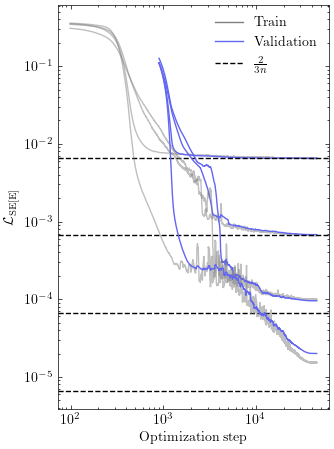

In [11]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

default_figsize = jnp.array((3.5, 2.625))
fig, ax = plt.subplots(1, 1, figsize=default_figsize * jnp.array([1, 2]))

for shots in shots_list:
    df = pl.read_csv(f"./shot-exp/{shots}/model/train_hist.csv")

    filtered_df = df.filter(pl.col("loop") == "train")
    x = filtered_df["step"].to_numpy()
    y = filtered_df["loss"].to_numpy()
    sq.visualization.plot_loss_with_moving_average(
        x=x, y=y, ax=ax, annotate_at=[], label=f"Train ({shots:,})", color=colors["gray"], window=100, alpha=0.5
    )

    filtered_df = df.filter(pl.col("loop") == "val")
    x = filtered_df["step"].to_numpy()
    y = filtered_df["loss"].to_numpy()
    sq.visualization.plot_loss_with_moving_average(
        x=x, y=y, ax=ax, annotate_at=[], label=f"Validation ({shots:,})", color=colors["blue"], window=100
    )

    ax.axhline(
        y=2 / (3 * shots),
        color="black",
        linestyle="dashed",
    )

ax.set_ylabel(r"$\mathcal{L}_{\mathrm{SE[E]}}$")
ax.set_xlabel("Optimization step")

sq.visualization.set_fontsize(ax, 10)

# Create custom legend
train_line = mlines.Line2D([], [], color=colors["gray"], label="Train")
test_line = mlines.Line2D([], [], color=colors["blue"], label="Validation")
threshold_line = mlines.Line2D([], [], color="black", linestyle="dashed", label=r"$\frac{2}{3n}$")

ax.legend(
    handles=[train_line, test_line, threshold_line],
    loc="best",
    # frameon=True
)

ax.set_yscale("log")
ax.set_xscale("log")
fig.savefig("figure_shot_train_loss.pdf")

In [12]:
key = jax.random.key(73)
for shots in shots_list:
    key, data_key, benchmark_key = jax.random.split(
        key, 3
    )

    loaded_data, train_data, test_data = prepare_data(data_key, shots)

    benchmark_results, exact_agf = benchmark(
        benchmark_key, shots, loaded_data.whitebox, detune=0.00075, filename='benchmark_result_drifted.json'
    )
    print(shots, exact_agf)

100 0.9957952870214368
1000 0.9981329160879322
10000 0.9980703886850499
100000 0.998134030330124


Shots        Exact AGF       Model           Absolute Error  Drifted        
100          0.999112        0.999127        0.000015        0.995795       
1,000        0.999939        0.999930        0.000009        0.998133       
10,000       0.999927        0.999947        0.000019        0.998070       
100,000      0.999937        0.999947        0.000011        0.998134       


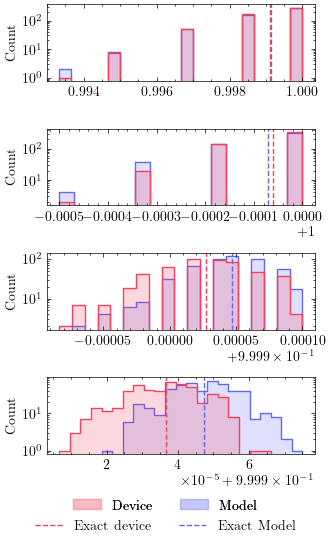

In [13]:
default_figsize = jnp.array((3.5, 2.625))
fig, axes = plt.subplots(4, 1, figsize=default_figsize * jnp.array([1, 2]))

axes = sq.visualization.assert_list_of_axes(axes)

rows = []

print("=" * 70)
print(f"{'Shots':<12} {'Exact AGF':<15} {'Model':<15} {'Absolute Error':<15} {'Drifted':<15}")
rows.append(["Shots", "Exact", "Model", "Absolute Error", "Drifted"])
print("=" * 70)

for shots, ax in zip(shots_list, axes):
    res = sq.experimental.data.load_pytree_from_json(
        f"./shot-exp/{shots}/model/benchmark_result.json"
    )

    drifted_res = sq.experimental.data.load_pytree_from_json(
        f"./shot-exp/{shots}/model/benchmark_result_drifted.json"
    )

    drifted_exact_agf = drifted_res['exact_agf']

    sns.histplot(
        res["benchmark_result"],
        palette={"Device": colors["red"], "Model": colors["blue"]},
        element="step",
        ax=ax,
        alpha=0.2,
    )

    predicted_agf = sq.experimental.data.load_pytree_from_json(
        f"./shot-exp/{shots}/model/optimized_control.json"
    )["predicted_agf"]
    exact_agf = res["exact_agf"]
    ax.axvline(exact_agf, color=colors["red"], linestyle="dashed")
    ax.axvline(
        predicted_agf,
        color=colors["blue"],
        linestyle="dashed",
    )

    ax.set_yscale("log")
    ax.legend([], [])
    # Print formatted report
    abs_agf_exact_predict = jnp.abs(exact_agf - predicted_agf).item()
    print(
        f"{shots:<12,} {exact_agf:<15.6f} {predicted_agf:<15.6f} {abs_agf_exact_predict:<15.6f} {drifted_exact_agf:<15.6f}"
    )
    formatted_shot = f"{shots:.0e}"
    mantissa, exponent = formatted_shot.split("e")
    exponent = int(exponent)
    rows.append([f"$10^{exponent}$", exact_agf, predicted_agf, abs_agf_exact_predict, drifted_exact_agf])

print("=" * 70)

# Create custom legend handles
device_patch = mpatches.Patch(color=colors["red"], label="Device", alpha=0.2)
model_patch = mpatches.Patch(color=colors["blue"], label="Model", alpha=0.2)

# Create line handles for the vertical lines
exact_line = mlines.Line2D(
    [], [], color=colors["red"], linestyle="dashed", label="Exact device"
)
model_mean_line = mlines.Line2D(
    [], [], color=colors["blue"], linestyle="dashed", label="Exact Model"
)

# Bottom of figure
# First legend for distributions
legend1 = fig.legend(
    handles=[device_patch, model_patch],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=2,
)

# Second legend for lines
fig.legend(
    handles=[exact_line, model_mean_line],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
)

# Keep the first legend (matplotlib only keeps the last one by default)
fig.add_artist(legend1)

plt.tight_layout()
# Adjust layout to make room for legend
plt.subplots_adjust(top=0.95)
fig.savefig("figure_agf_histogram.pdf")

In [ ]:
# Example 1: Default precision
print(pra_table(
    rows,
    caption="Comparison of exact and predicted AGF for varying shot counts. The absolute error is the absolute difference between the exact and predicted AGF. We also list the AGF using the same optimized control variable but execute on the device with qubit frequency $\omega_{q} = 5.00075 \si{GHz}$ instead of $\omega_{q} = 5.0005 \si{GHz}$ in the exact column.",
    label="tab:agf-comparison",
    precision=5
))


\begin{table}[htbp]
\centering
\begin{ruledtabular}\begin{tabular}{lrrrr}
\textbf{Shots} & \textbf{Exact} & \textbf{Model} & \textbf{Absolute Error} & \textbf{Drifted} \\
\midrule
$10^2$ & 0.99911 & 0.99913 & $1.54831 \times 10^{-5}$ & 0.99580 \\
$10^3$ & 0.99994 & 0.99993 & $9.39671 \times 10^{-6}$ & 0.99813 \\
$10^4$ & 0.99993 & 0.99995 & $1.92829 \times 10^{-5}$ & 0.99807 \\
$10^5$ & 0.99994 & 0.99995 & $1.07543 \times 10^{-5}$ & 0.99813 \\
\end{tabular}
\end{ruledtabular}\caption{Comparison of exact AGF and model predictions for varying shot counts.}
\label{tab:agf-comparison}
\end{table}


In [15]:
for shots in shots_list:
    data_var = sq.experimental.utils.variance_of_observable(testing_datasets[shots].observables, shots=shots).mean()
    print(f"Empirical Data Variance of n = {shots:<8}", data_var)

Empirical Data Variance of n = 100      0.006601047555555554
Empirical Data Variance of n = 1000     0.0006662010231111112
Empirical Data Variance of n = 10000    6.665761423355556e-05
Empirical Data Variance of n = 100000   6.6663916670646665e-06


In [ ]:
def inverse_bound(abs_agf, shots: int):
    return (4 / 3) * (abs_agf) ** 2 + 2 / (3 * shots)


default_figsize = jnp.array((3.5, 2.625))
fig, axes = plt.subplots(4, 1, figsize=default_figsize * jnp.array([1, 2.5]))
axes = sq.visualization.assert_list_of_axes(axes)

y_targets = [1e-3, 1e-4]  # Target y-values for annotation

for idx, (shots, ax) in enumerate(zip(shots_list, axes)):
    se_range = jnp.linspace(2 / (3 * shots), 2 / (3 * shots) * (1.05), 100)
    abs_agf = bound(se_range, shots)

    ax.plot(se_range, abs_agf, color=colors["blue"])
    ax.set_yscale("log")
    ax.ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))

    x_min, x_max = se_range[0], se_range[-1]

    ax.set_xlim((x_min - (x_min * 0.005)).item(), x_max.item())

    if shots == 100_000:
        ax.set_xlabel(r"$\mathbb{E}_{x, y}[ \mathcal{L}_{\text{SE[E]}} ]$")

    for y_target in y_targets:
        ax.axhline(y=y_target, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
        x_intersect = inverse_bound(y_target, shots)
        x_intersect_text = format_value(x_intersect, scientific_threshold=0.1, precision='4')
        ax.axvline(
            x=x_intersect, color="gray", linestyle="--", linewidth=0.8, alpha=0.6
        )
        ax.plot(x_intersect, y_target, "o", markersize=4, color=colors['red'])

        # Determine if point is on left or right half
        if x_intersect < (x_min + x_max) / 2:
            # Point on left, place text on right
            ax.annotate(
                x_intersect_text,
                xy=(x_intersect, y_target),
                xytext=(15, 2),
                textcoords="offset points",
                fontsize=7,
                ha="left",
                va="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
            )
        else:
            # Point on right, place text on left
            ax.annotate(
                x_intersect_text,
                xy=(x_intersect, y_target),
                xytext=(-15, 2),
                textcoords="offset points",
                fontsize=7,
                ha="right",
                va="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
            )
    
    # Add subplot title with label and shot count
    label = chr(97 + idx)  # 97 is ASCII for 'a'
    formatted_shot = f"{shots:.0e}"
    mantissa, exponent = formatted_shot.split('e')
    exponent = int(exponent)
    ax.set_title(f"({label}) shots = $10^{exponent}$")

fig.suptitle(r"Plot of $\mathbb{E}_{x} \big[ |\bar{F}_{\mathrm{model}} - \bar{F}_{\mathrm{exact}}| \big]$")
fig.tight_layout()
fig.savefig("figure_bound_plot.pdf")

In [ ]:
def optimality_bound(optimality):
    return jnp.sqrt((3 / 4) * optimality)

def inverse_optimality_bound(abs_agf):
    return (abs_agf**2) * (4/3)
fig, ax = plt.subplots(figsize=default_figsize * jnp.array([1, 1.]))

optimality_range = jnp.logspace(-9, -1, 100)
agf_bound = optimality_bound(optimality_range)

ax.plot(optimality_range, agf_bound, color=colors['blue'], linewidth=2, label='Bound')

# Add gridlines at specific y-values
y_targets = [1e-2, 1e-3, 1e-4]
for y_target in y_targets:
    # Horizontal dashed line
    ax.axhline(y=y_target, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
    
    # Calculate x-value using inverse function
    x_intersect = inverse_optimality_bound(y_target)
    x_intersect_text = format_value(x_intersect, scientific_threshold=0.1, precision='2')
    y_target_text = format_value(y_target, scientific_threshold=0.1, precision=0)
    
    # Only draw vertical line if intersection is within the plot range
    if optimality_range[0] <= x_intersect <= optimality_range[-1]:
        ax.axvline(x=x_intersect, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)
        
        # Add intersection point marker
        ax.plot(x_intersect, y_target, 'o', color=colors['red'], markersize=5, zorder=5)
        
        # Annotate with coordinates
        ax.text(x_intersect, y_target * 1.5, 
                # f"({x_intersect_text}, {y_target_text})",
                f"{x_intersect_text}",
               fontsize=8, ha='center', va='bottom',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

ylabel = r"$\mathbb{E}_{x} \left[ |\bar{F}_{\mathrm{model}} - \bar{F}_{\mathrm{exact}}| \right]$"
ax.set_ylabel(ylabel, fontsize=11)
xlabel = r"$\mathbb{E}_{x}\big[ (\check{f}(x) - \mathbb{E}[y|x] )^2 \big]$"
ax.set_xlabel(xlabel, fontsize=11)
ax.set_yscale("log")
ax.set_xscale("log")
ax.grid(True, alpha=0.3, which='both', linestyle=':', linewidth=0.5)
ax.legend(loc='best', framealpha=0.9)

fig.tight_layout()
fig.savefig("figure_optimality_bound.pdf")